In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def gen_matrix(t): 
    alpha1, alpha2 = np.random.uniform(0, 2 * np.pi), np.random.uniform(0, 2 * np.pi)
    
    t1, t2 = np.cos(alpha1) + 1j * np.sin(alpha1), np.cos(alpha2) + 1j * np.sin(alpha2)

    return np.array([
        [1, t, 1, 1j], 
        [-1, t2, 1j, t1], 
        [1j, 1, 0, 1j], 
        [-1j, 0, -1j, 1j]
    ])

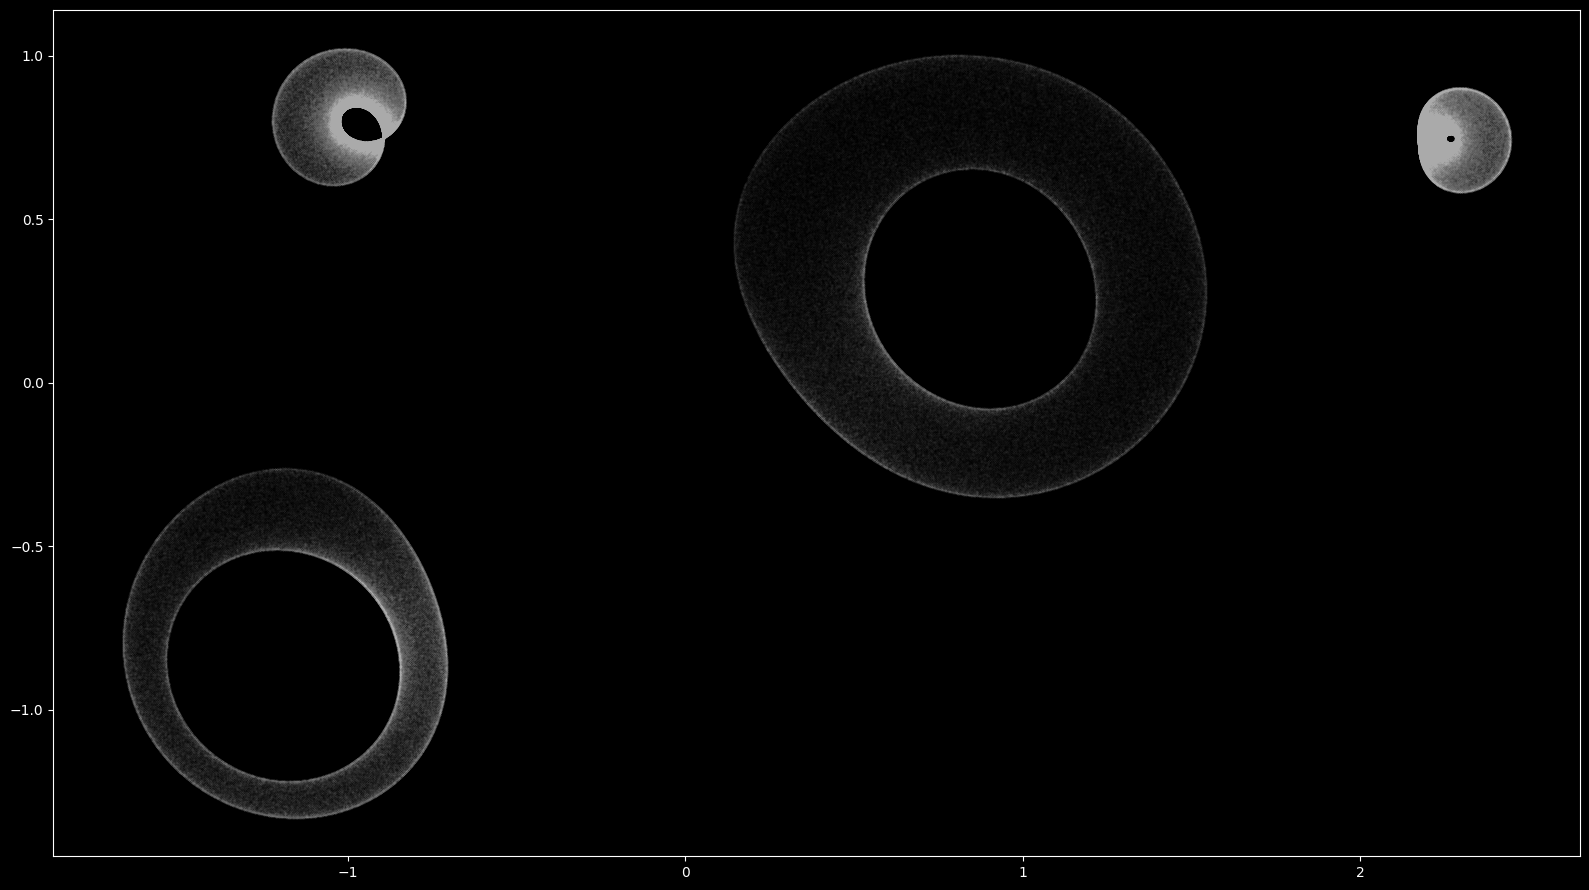

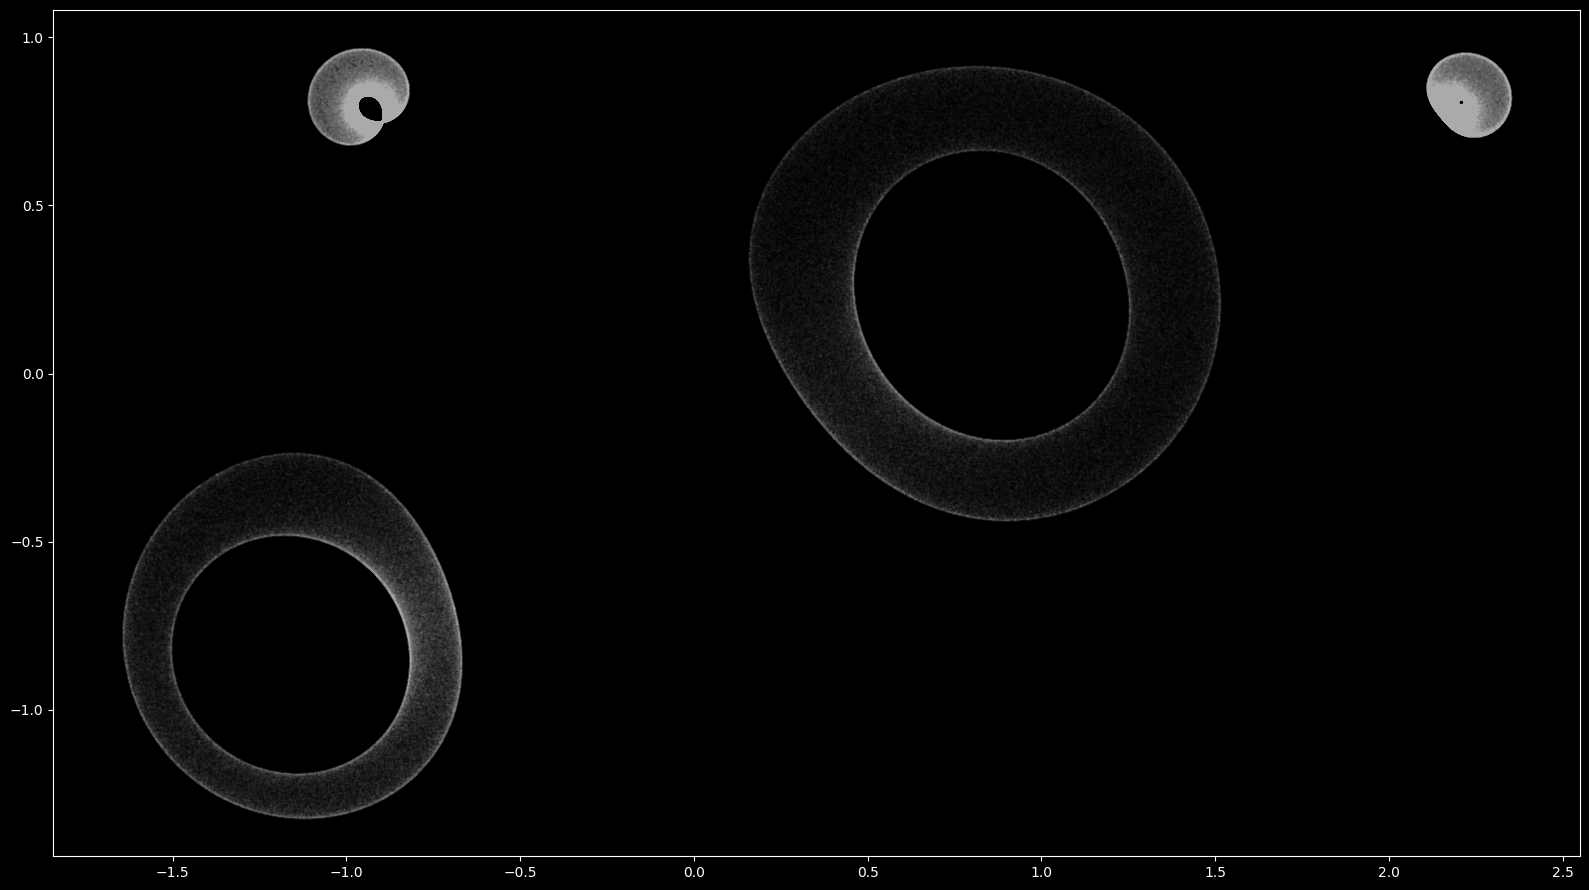

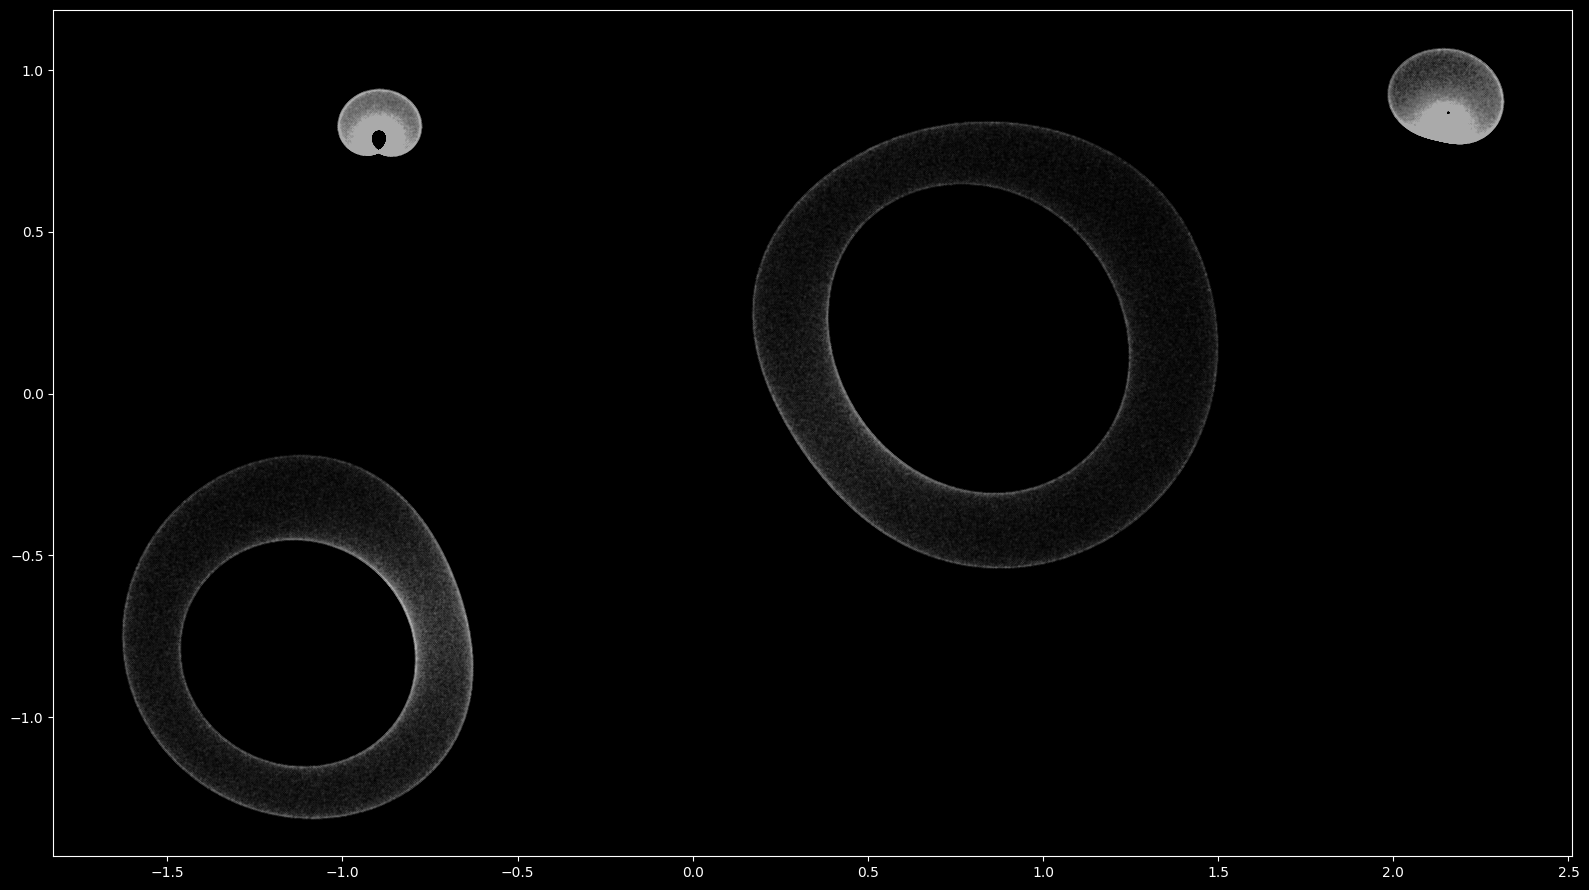

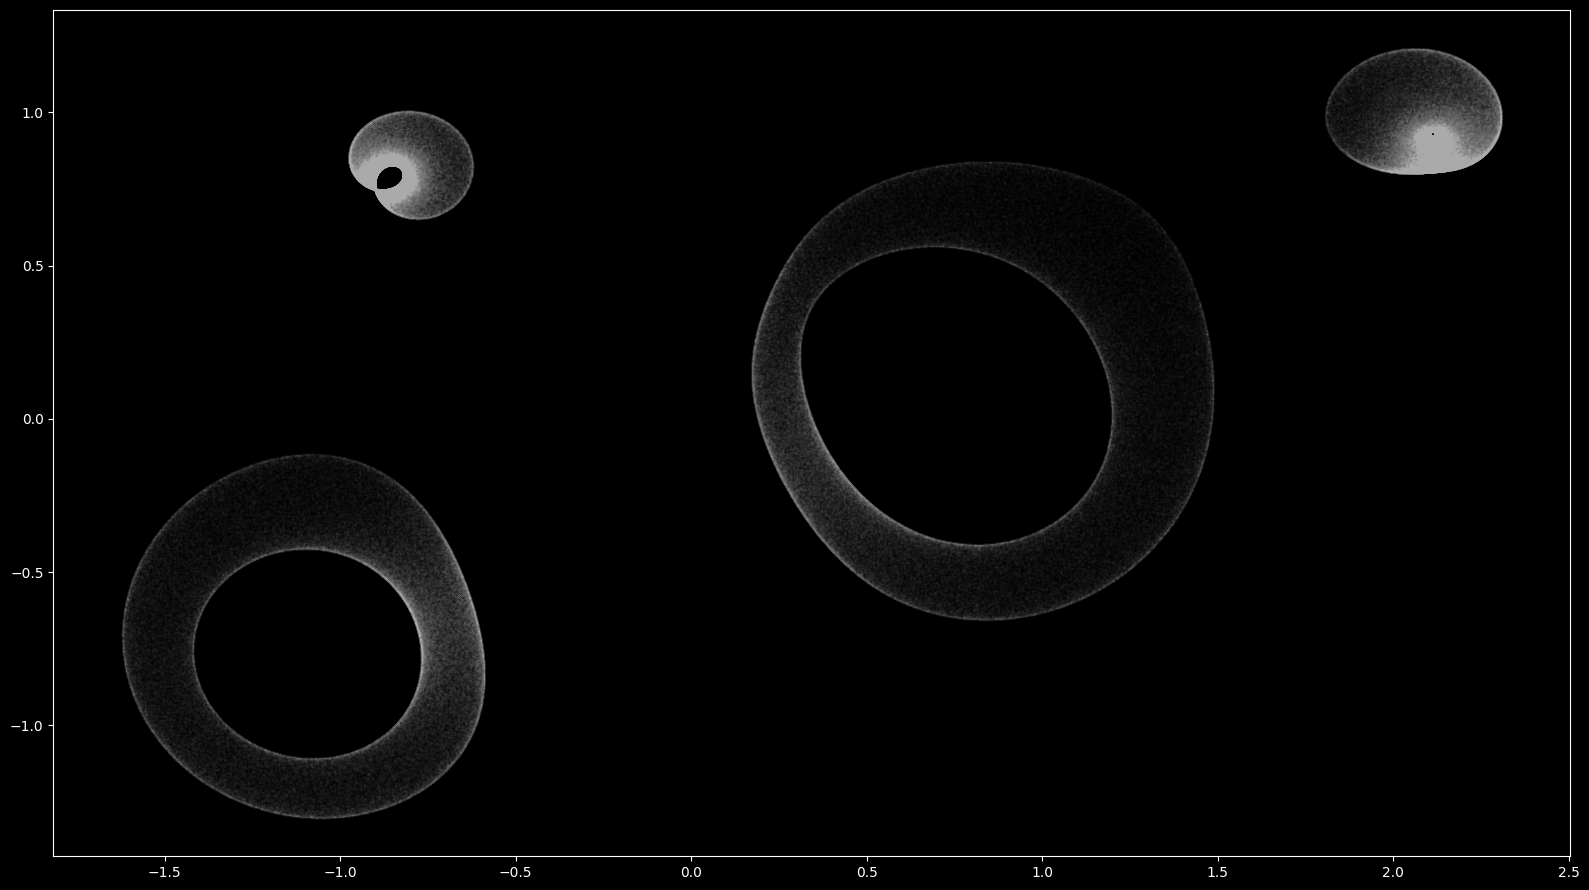

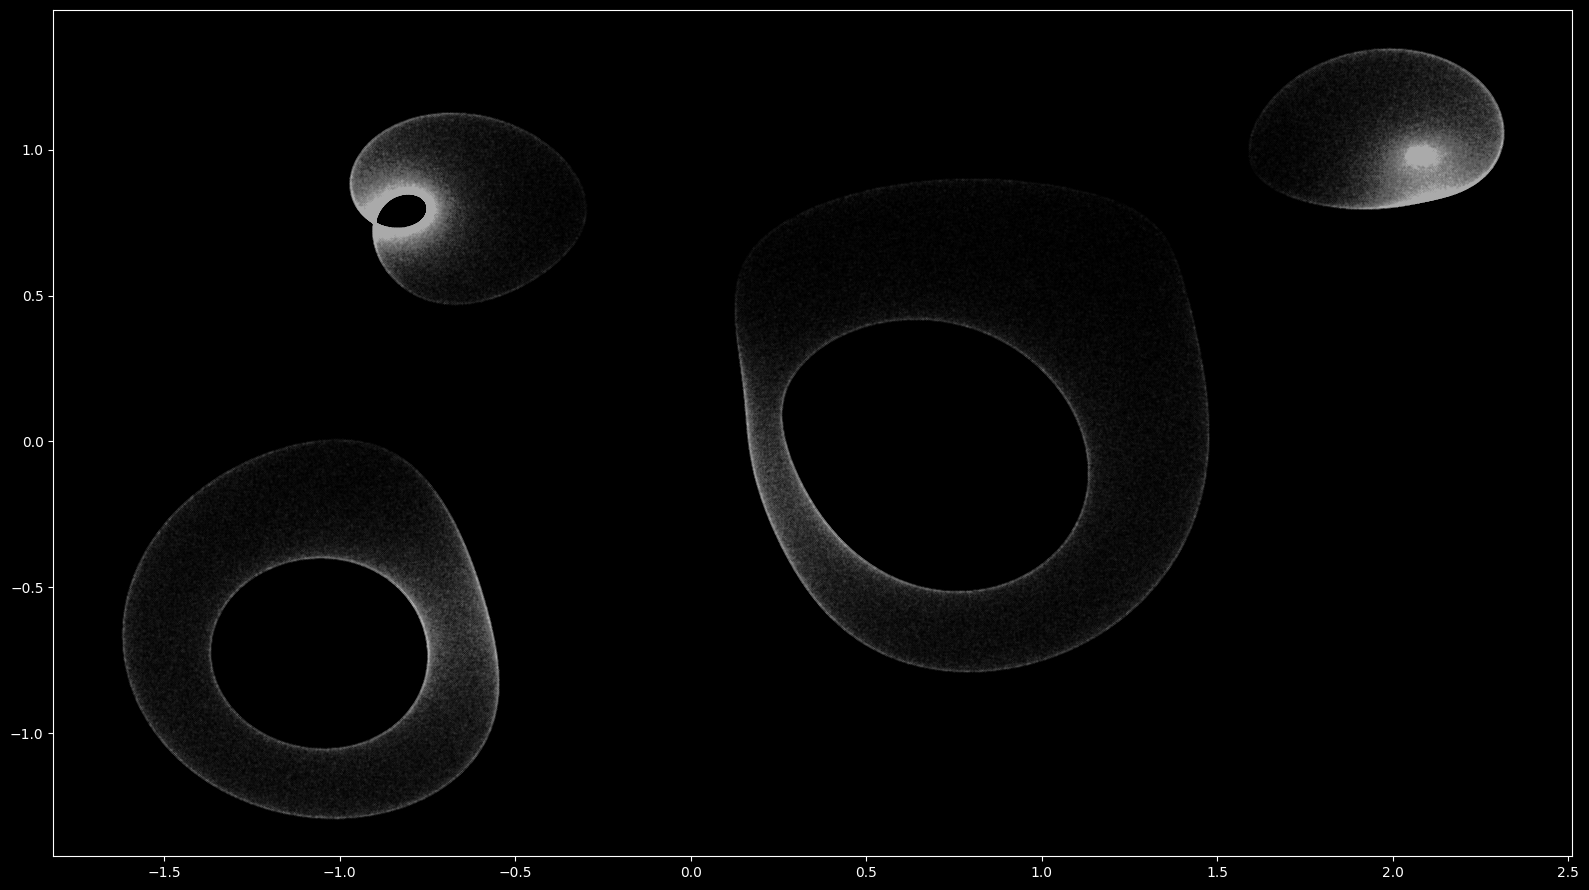

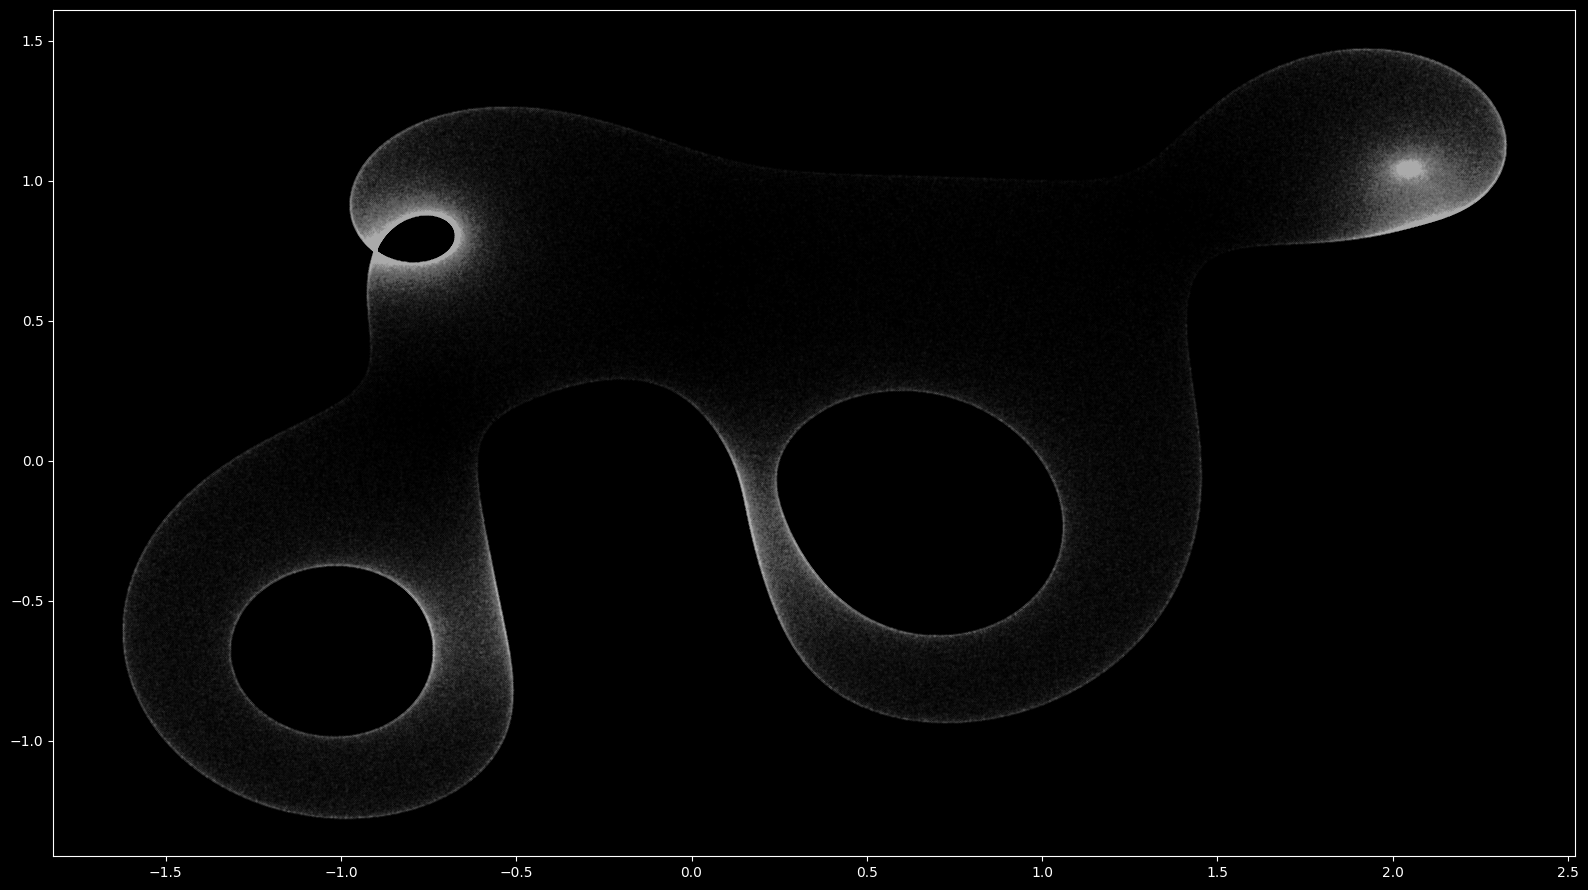

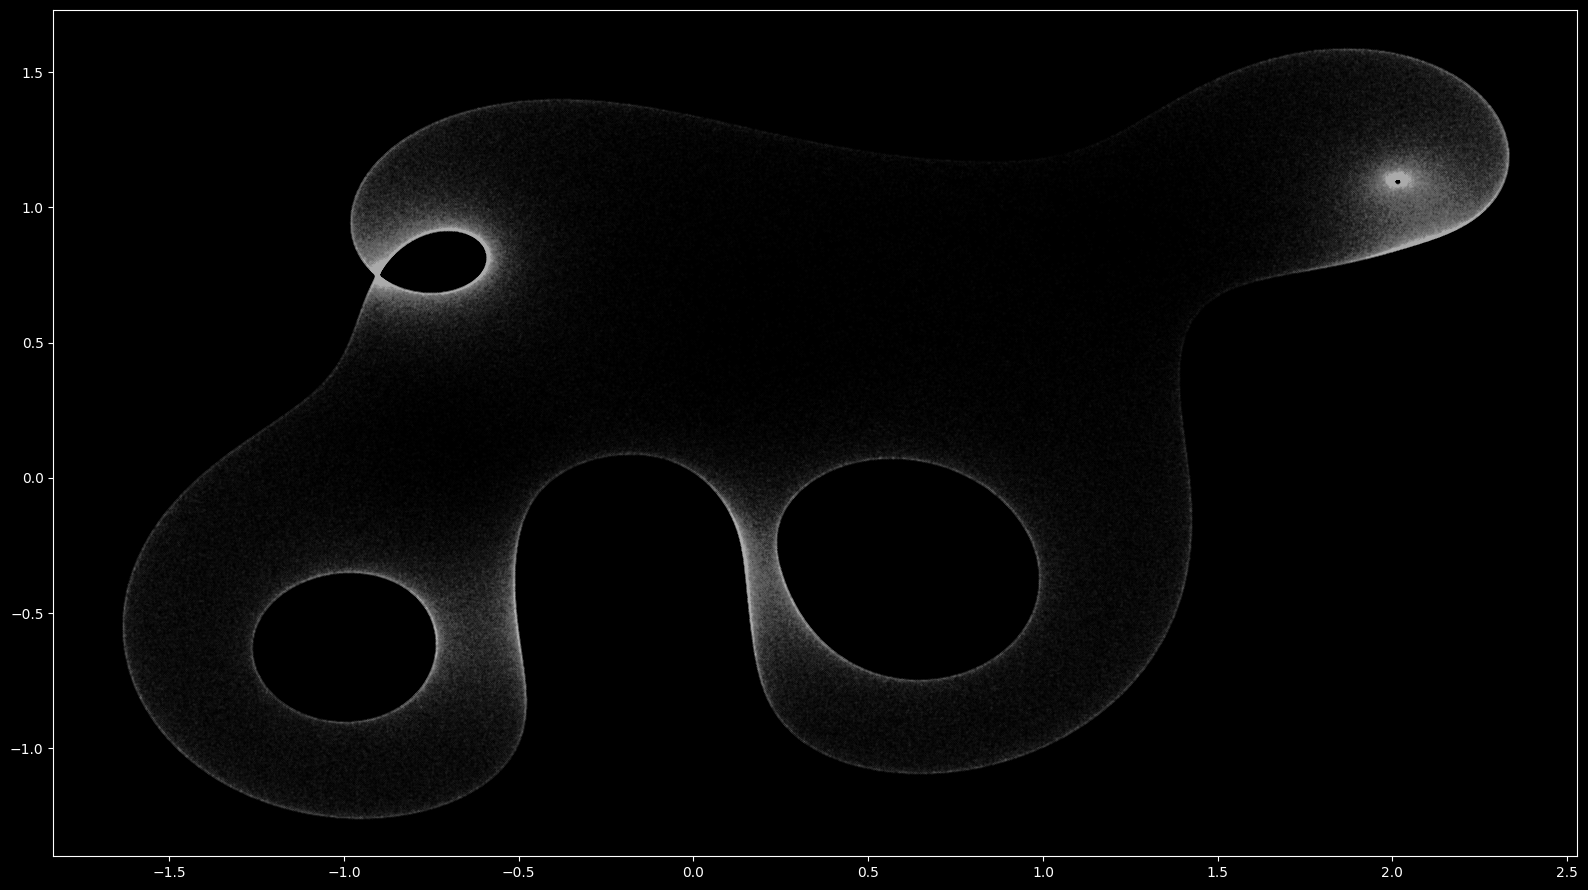

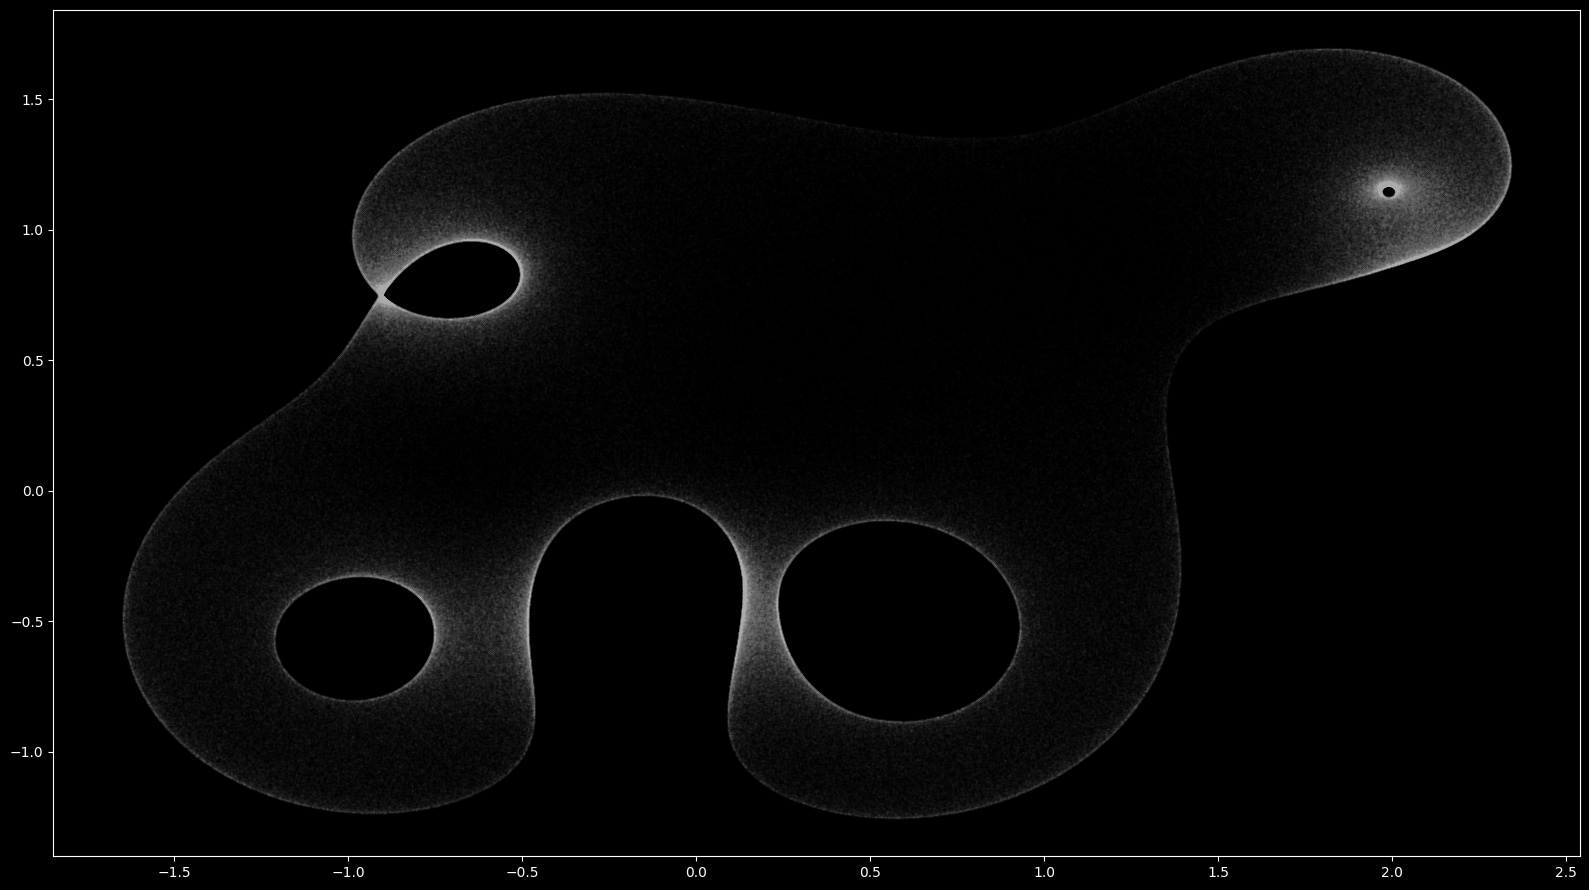

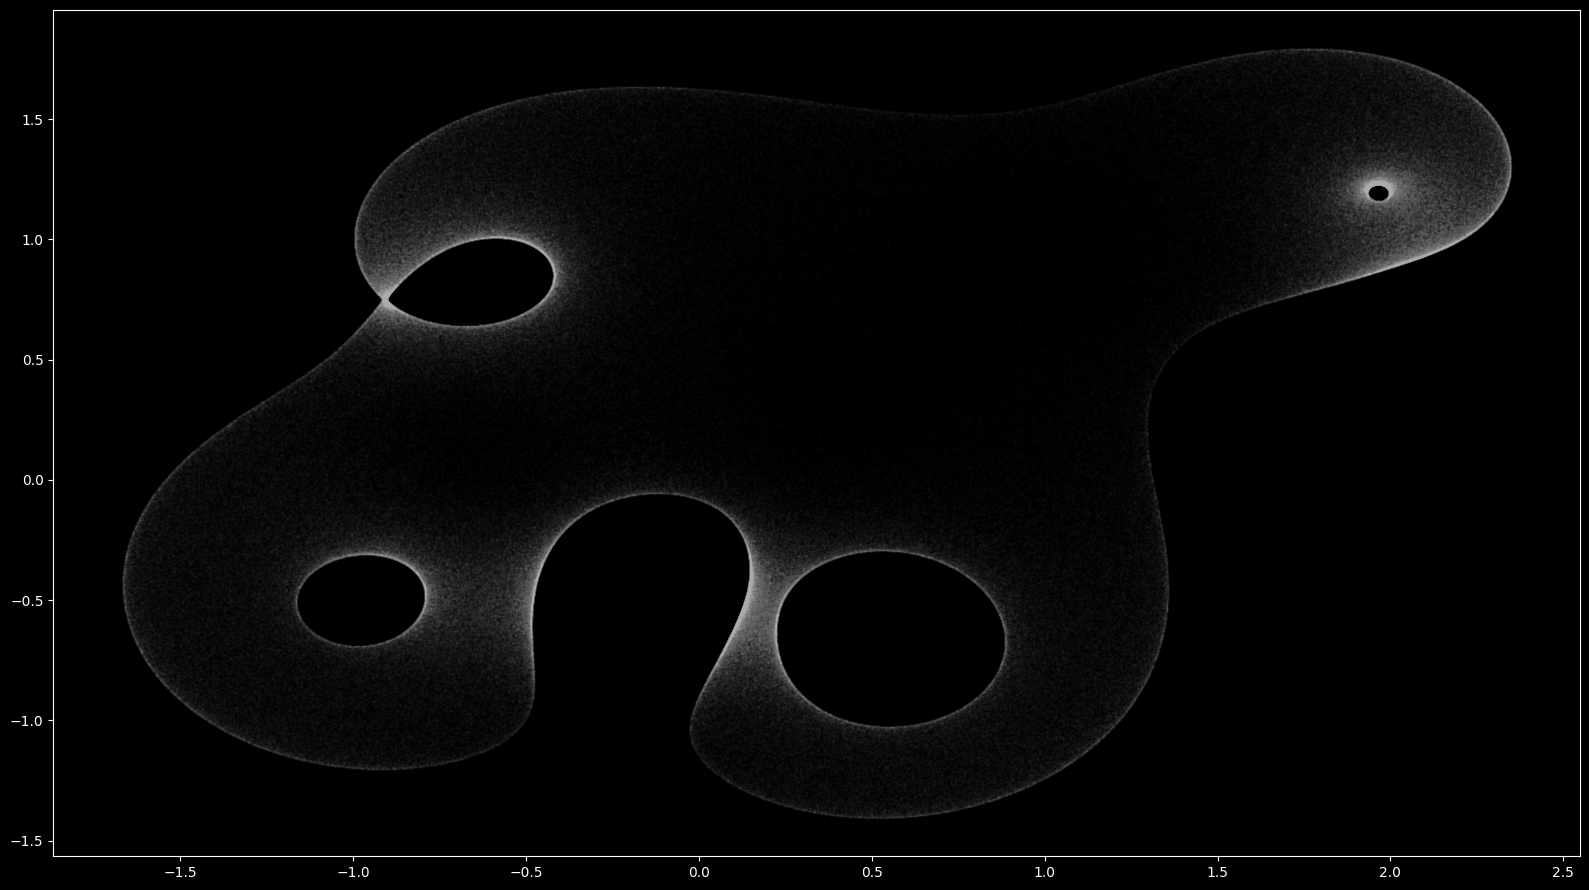

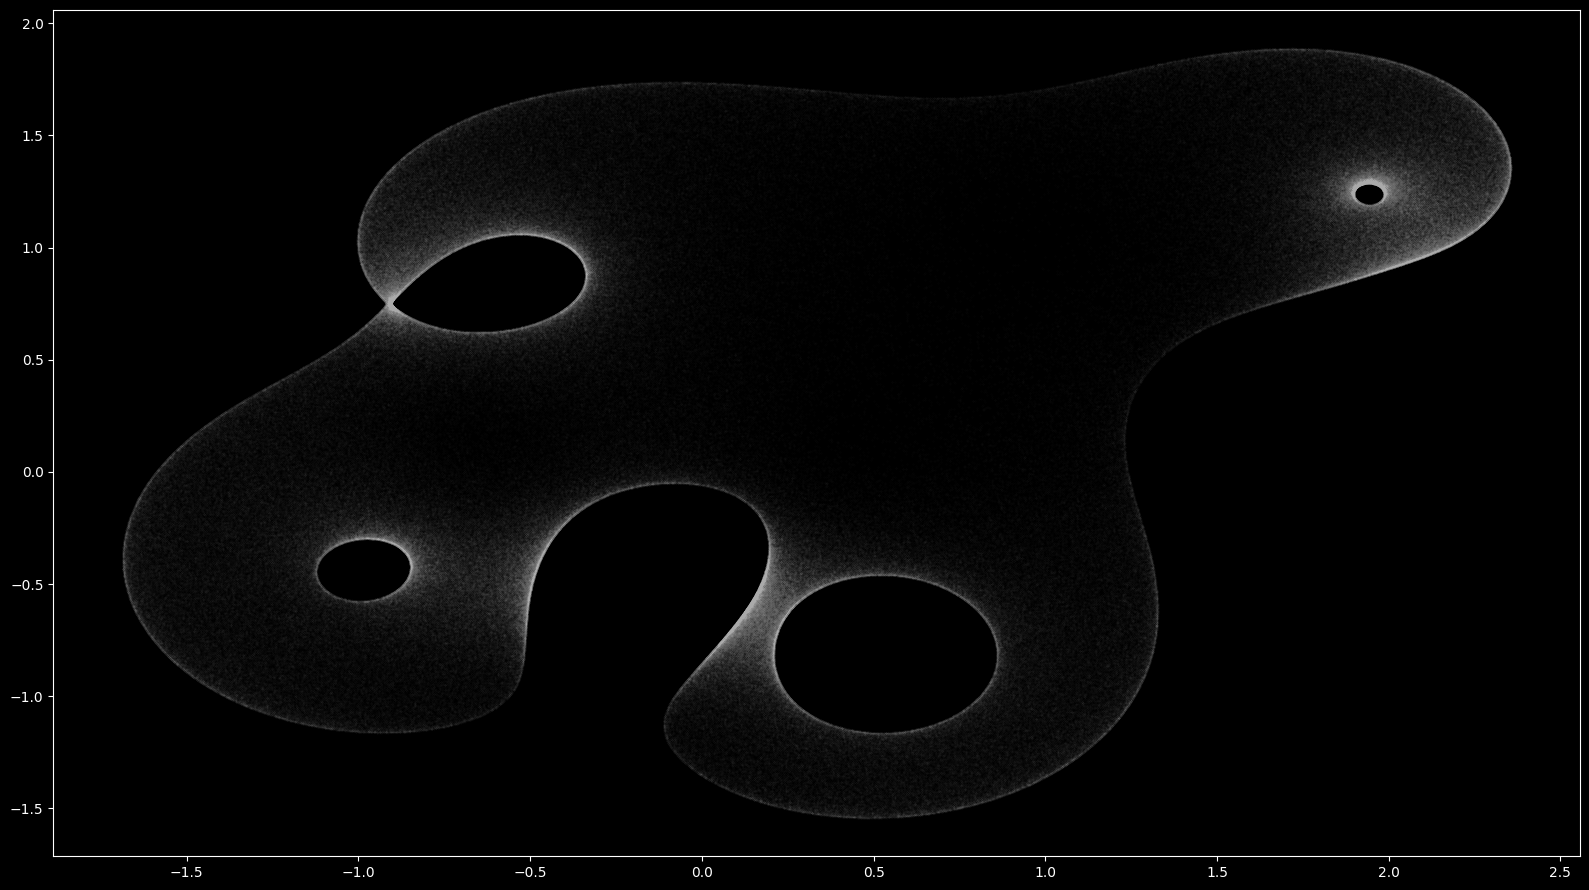

In [6]:
for idx, t in enumerate(np.linspace(-1, 1, 10)): 

    with open('data.csv', 'w') as f:

        batch_counter = 0

        for i in range(1_00_000):
            matrix = gen_matrix(t)

            lambdas = np.linalg.eigvals(matrix)
            
            # lambdas = [lambd for lambd in lambdas if lambd.imag != 0]
            
            for lambd in lambdas:
                f.write(f"{lambd.real:.6f},{lambd.imag:.6f}\n")
            
            batch_counter += len(lambdas)

        
        plt.figure(figsize=(16, 9))

    color = 'white'

    alpha = 0.03
    s = 0.1

    try:
        data = np.loadtxt('data.csv', delimiter=',')
        if len(data) > 0:
            real_parts = data[:, 0]
            imag_parts = data[:, 1]

            plt.scatter(real_parts, imag_parts, color=color, alpha=alpha, s=s)
            
    except MemoryError:
        chunk_size = 100_000
        all_data = []
        
        with open('data.csv', 'r') as f:
            chunk = []
            for line in f:
                parts = line.strip().split(',')
                if len(parts) == 2:
                    chunk.append([float(parts[0]), float(parts[1])])
                
                if len(chunk) >= chunk_size:
                    chunk_arr = np.array(chunk)
                    plt.scatter(chunk_arr[:, 0], chunk_arr[:, 1], color=color, alpha=alpha, s=s)
                    chunk = []
            
            if chunk:
                chunk_arr = np.array(chunk)
                plt.scatter(chunk_arr[:, 0], chunk_arr[:, 1], color=color, alpha=alpha, s=s)

    plt.xlim(-2, 2)
    plt.ylim(-2, 2)

    plt.axis('off')

    plt.tight_layout()
    plt.savefig(f'test2/eigenvalues_{idx}.png', dpi=200)
